## Univariate Analysis: Exploration of Individual Features

This notebook focuses on **Univariate Analysis**, the process of describing and summarizing individual variables. The goal is to understand the distribution, central tendency, and spread of each feature in the Titanic dataset before exploring complex relationships.

---

### Objectives
* **Categorical Features:** Identify the frequency and balance of classes (e.g., Survival rates, Gender ratios, Passenger Class distribution).
* **Numerical Features:** Analyze the "shape" of data, identifying skewness and potential outliers in features like `Age` and `Fare`.

### Visualization Strategy
* **Count Plots:** For categorical data (e.g., `Sex`, `Embarked`).
* **Histograms & KDE:** For continuous data (e.g., `Age`).
* **Box Plots:** To detect outliers and visualize the interquartile range.

In [1]:
# imports
from helpers.prepare import *
from helpers.visualization import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=prepare_data('train.csv')
df.head()

The Number of Duplicated Rows =  0
The Number of Raws in the data =  891


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,Died,Third Class,male,22.0,1,0,7.2500,S
1,Survived,First Class,female,38.0,1,0,71.2833,C
2,Survived,Third Class,female,26.0,0,0,7.9250,S
3,Survived,First Class,female,35.0,1,0,53.1000,S
4,Died,Third Class,male,35.0,0,0,8.0500,S


In [3]:
# this will show the distribution of the numerical data
df[['Age','Fare']].describe(include='float')

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [4]:
# show the distribution of the categorical columns
df.describe(include=['category','object'])

,Survived,Pclass,Sex,Embarked
count,891,891,891,889
unique,2,3,2,3
top,Died,Third Class,male,S
freq,549,491,577,644


### Numerical Distribution Analysis

The following observations summarize the distribution and characteristics of the continuous numerical features:

---

#### 1. Statistical Findings
* **Age Distribution:** * The feature exhibits a **positive (right) skew**, with the mean ($29.7$) exceeding the median ($28.0$).
    * The presence of a maximum value of $80$ suggests potential **outliers** in the upper tail of the distribution.
* **Fare Distribution:** * This feature shows a **significant right skew**; the mean ($32.2$) is more than double the median ($14.45$), indicating heavy-tailed data.
    * A maximum value of $512.33$ points toward extreme **outliers** (luxury tickets).
    * **Data Anomaly:** The minimum value is **0.00**. This warrants further investigation, as it may represent missing data, complimentary tickets, or crew member records.
    
    
## Categorical columns Analysis:
### Survived:


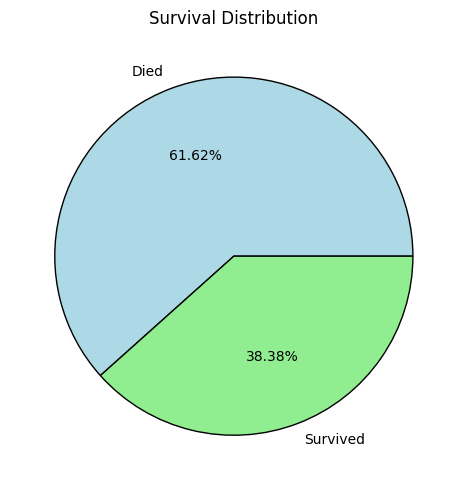

In [5]:
to_draw=df['Survived'].value_counts()
draw_pie(to_draw,'Survival Distribution')

### Survival Distribution

* **Died:** 62% (549 data sample)
* **Survived:** 38% (342 data sample)

**Observation:** There is a notable disparity in survival, with the mortality rate exceeding the survival rate by 24 percentage points. This distribution serves as the primary benchmark for all subsequent analysis.

## P-Class Distribution

In [6]:
to_draw=df['Pclass'].value_counts()


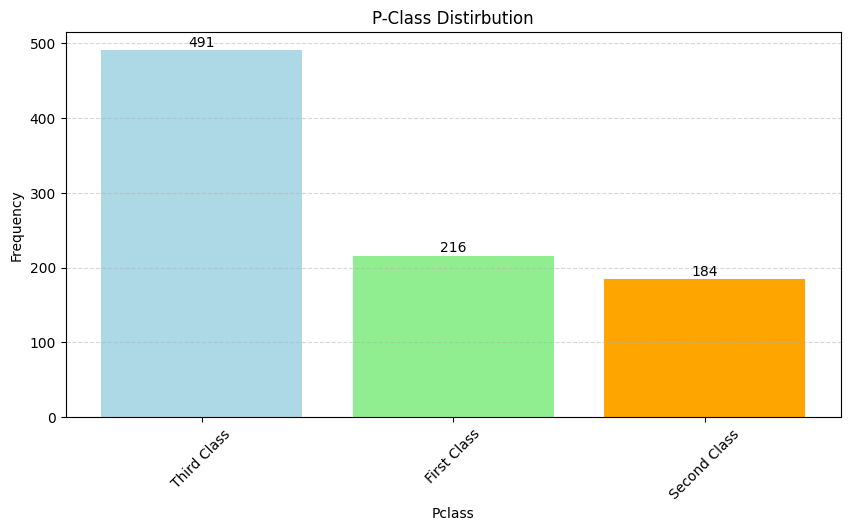

In [7]:
draw_bar(to_draw,5,'Pclass','Frequency','P-Class Distirbution')

### Passenger Class Distribution

* **Third Class:** 55% (491 passengers)
* **First Class:** 24% (216 passengers)
* **Second Class:** 21% (184 passengers)

**Observation:** The majority of passengers were in Third Class, nearly doubling the count of First and Second Class combined. This highlight's the dataset's focus on the socio-economic structure of the ship's population.

## Gender Column:

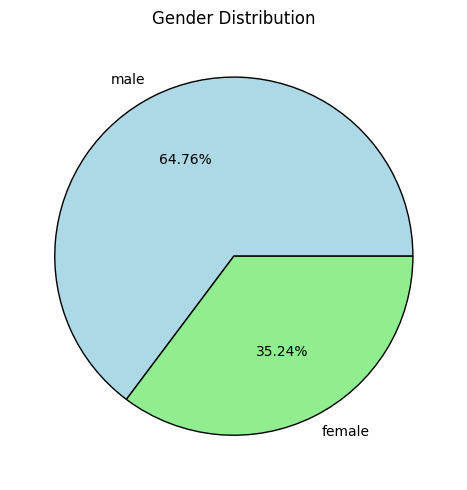

In [10]:
to_draw=df['Sex'].value_counts()
draw_pie(to_draw,'Gender Distribution')

### Gender Distribution

* **Male:** 65% (577 passengers)
* **Female:** 35% (314 passengers)

**Observation:** The passenger population was predominantly male, accounting for nearly two-thirds of the total count. This demographic baseline is essential for analyzing the "women and children first" evacuation policy.

## SibSp Column

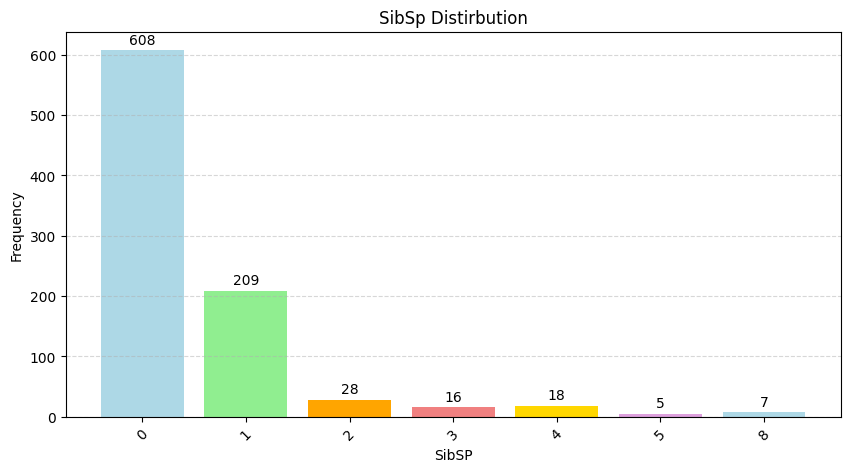

In [19]:
to_draw=df['SibSp'].astype('str').value_counts().sort_index()
draw_bar(to_draw,10,'SibSP','Frequency','SibSp Distirbution')

### Sibling/Spouse Distribution ($SibSp$)

* **No Siblings/Spouses:** $68\%$ ($608$ passengers)
* **One Sibling/Spouse:** $23\%$ ($209$ passengers)
* **Two or More ($2+$):** $9\%$ ($74$ passengers)

**Observation:** The vast majority of passengers traveled alone or with only one sibling or spouse. There is a significant drop-off in frequency for larger family groups, indicating that most travelers had a minimal family footprint in this specific category.

### Parch

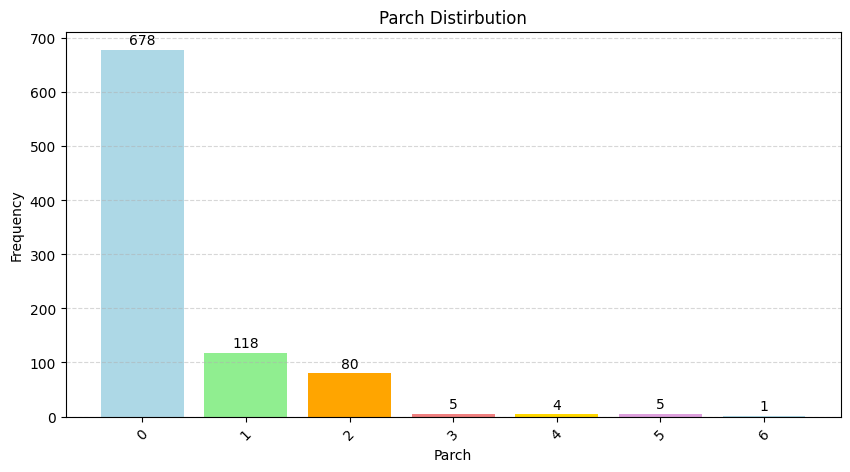

In [21]:
to_draw=df['Parch'].astype('str').value_counts().sort_index()
draw_bar(to_draw,10,'Parch','Frequency','Parch Distirbution')

In [22]:
to_draw

Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

### Parent/Child Distribution ($Parch$)

* **No Parents/Children:** $76\%$ ($678$ passengers)
* **One Parent/Child:** $13\%$ ($118$ passengers)
* **Two or More ($2+$):** $11\%$ ($95$ passengers)

**Observation:** Over three-quarters of the passengers traveled without parents or children. While small family units ($1$-$2$ members) are represented, larger multi-generational families are extremely rare, with very few passengers traveling with more than two parents or children.

## Creating Alone Traveller Column:

In [23]:
## Creating the new column
df['alone Traveller'] = (df['SibSp'] == 0) & (df['Parch'] == 0)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,alone Traveller
0,Died,Third Class,male,22.0,1,0,7.2500,S,False
1,Survived,First Class,female,38.0,1,0,71.2833,C,False
2,Survived,Third Class,female,26.0,0,0,7.9250,S,True
3,Survived,First Class,female,35.0,1,0,53.1000,S,False
4,Died,Third Class,male,35.0,0,0,8.0500,S,True
...,...,...,...,...,...,...,...,...,...
886,Died,Second Class,male,27.0,0,0,13.0000,S,True
887,Survived,First Class,female,19.0,0,0,30.0000,S,True
888,Died,Third Class,female,NaN,1,2,23.4500,S,False
889,Survived,First Class,male,26.0,0,0,30.0000,C,True


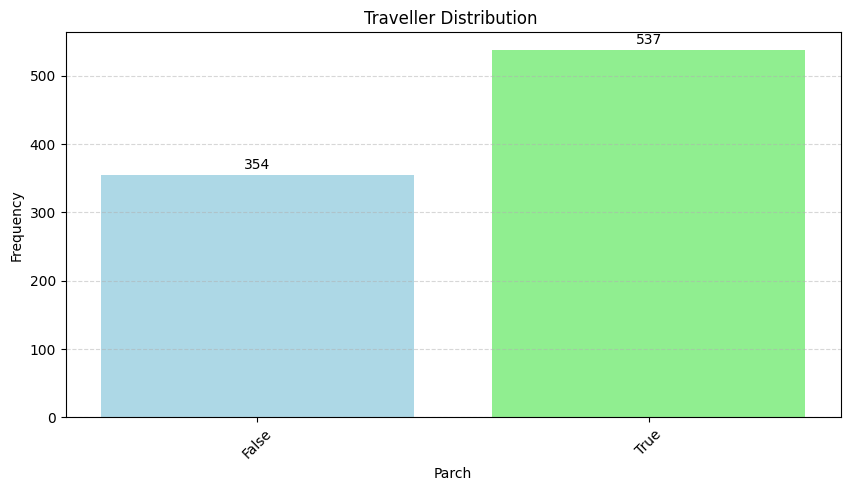

In [25]:
to_draw=df['alone Traveller'].astype('str').value_counts().sort_index()
draw_bar(to_draw,10,'Parch','Frequency','Traveller Distribution ')

Embarked
C      168
Q       77
S      644
nan      2
Name: count, dtype: int64

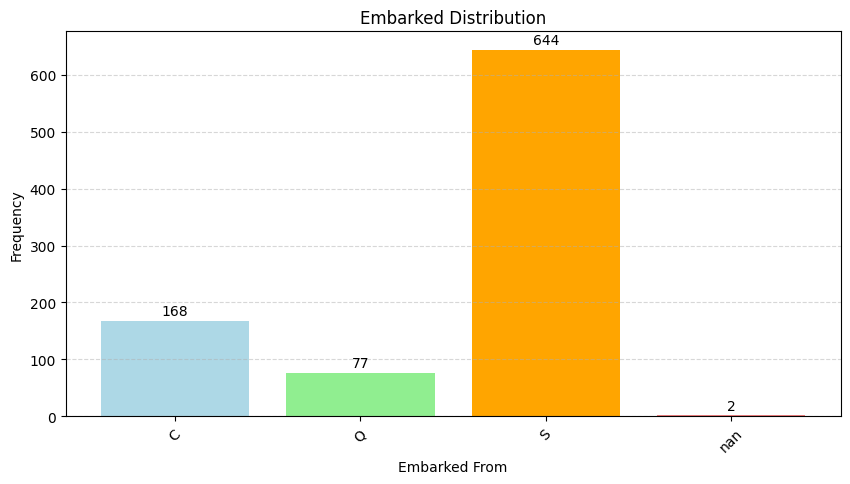

In [27]:
to_draw=df['Embarked'].astype('str').value_counts().sort_index()
display(to_draw)
draw_bar(to_draw,10,'Embarked From','Frequency','Embarked Distribution')

### Port of Embarkation Distribution (`Embarked`)

* **Southampton (S):** $72\%$ ($644$ passengers)
* **Cherbourg (C):** $19\%$ ($168$ passengers)
* **Queenstown (Q):** $9\%$ ($77$ passengers)
* **Missing (NaN):** $<1\%$ ($2$ passengers)

**Observation:** The vast majority of passengers boarded at Southampton, making it the primary point of origin for the voyage. The two missing values are negligible.

# Age Distribution

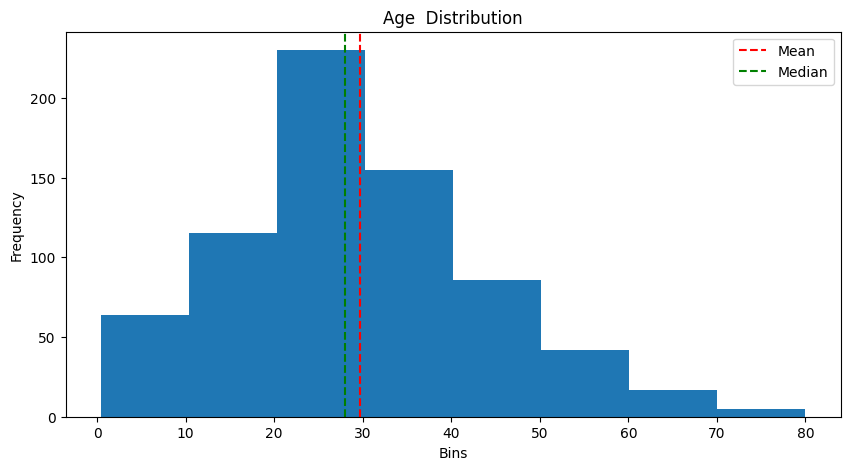

In [31]:
draw_hist(df['Age'],'Age')

#### you have to comment on the visual
## make the outliers Detection (your task)

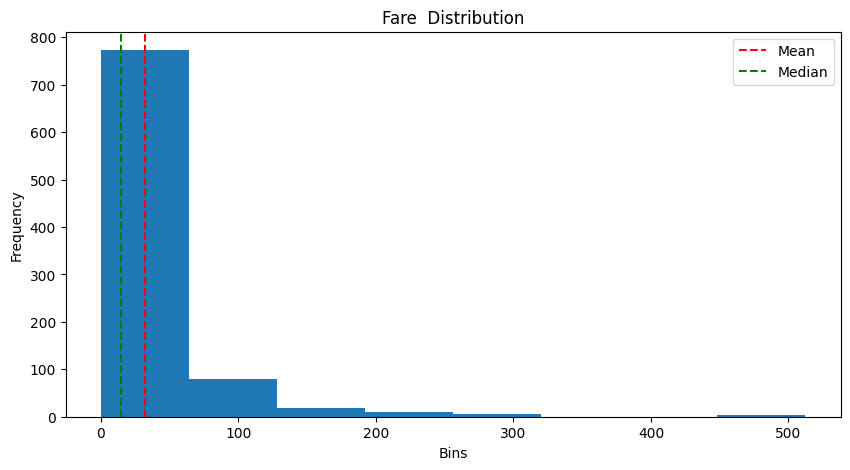

In [34]:
draw_hist(df['Fare'],'Fare')

you have to comment on the visual